<a href="https://colab.research.google.com/github/abrown12005/BME-4972_4973/blob/main/ImagesInMedicine/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_ind

RunningInCOLAB = 'google.colab' in str(get_ipython())
if RunningInCOLAB:
    # clone github repo with the data
    !git clone https://github.com/abrown12005/BME-4972_4973.git
    %cd BME-4972_4973/ImagesInMedicine

#Load and read the data
file_path = 'HW4.csv'
data = pd.read_csv(file_path,header=None)

healthy = data[0].to_numpy()
Schmooples = data[1].to_numpy()

Cloning into 'BME-4972_4973'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 45 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 167.69 KiB | 1.69 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine


P-Value:1.4108101454349842e-14
T-Statistic:-8.32


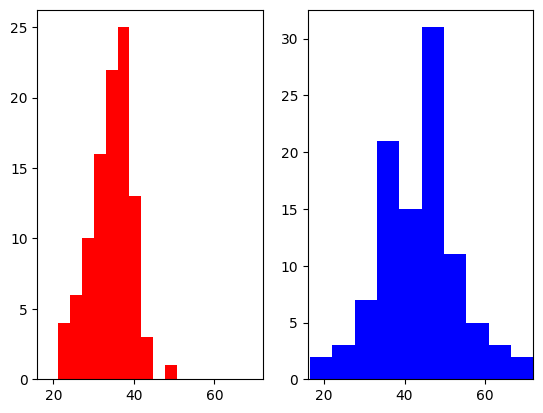

In [60]:
#Problem 1
#What is the probability that these two results came from the same dataset?
t_test = ttest_ind(healthy,Schmooples)

#Get the max and min to have the same x limits
x_max = np.maximum(np.max(healthy),np.max(Schmooples))
x_min = np.minimum(np.min(healthy),np.min(Schmooples))

fig, (ax1,ax2) = plt.subplots(1,2)
ax1.hist(healthy,color='r',bins=10)
ax1.set_xlim(int(x_min),int(x_max))

ax2.hist(Schmooples,color='b',bins=10)
ax2.set_xlim(int(x_min),int(x_max))

print(f'P-Value:{t_test.pvalue}')
print(f'T-Statistic:{t_test.statistic:.4}')

With a pvalue that low and a t-statistic that high, it is very unlikely that these two sets of results emerged from the same dataset.

(array([ 2.,  0.,  2.,  2.,  3.,  1.,  4.,  5.,  1.,  6.,  3.,  7.,  5.,
         6., 11.,  7., 11.,  7.,  4.,  4.,  5.,  1.,  2.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([21.177302  , 22.16119252, 23.14508305, 24.12897357, 25.11286409,
        26.09675462, 27.08064514, 28.06453567, 29.04842619, 30.03231671,
        31.01620724, 32.00009776, 32.98398828, 33.96787881, 34.95176933,
        35.93565985, 36.91955038, 37.9034409 , 38.88733143, 39.87122195,
        40.85511247, 41.839003  , 42.82289352, 43.80678404, 44.79067457,
        45.77456509, 46.75845562, 47.74234614, 48.72623666, 49.71012719,
        50.69401771]),
 <BarContainer object of 30 artists>)

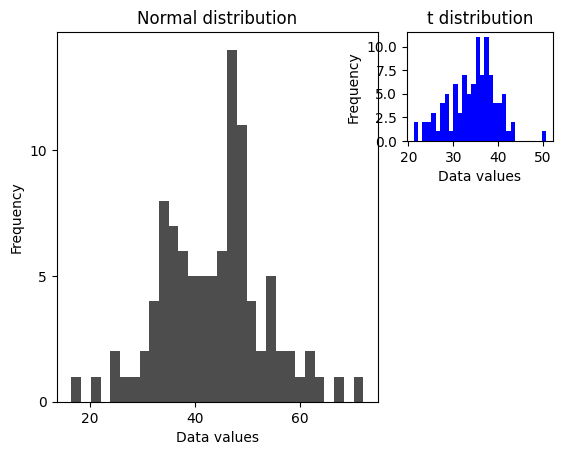

In [69]:
#Problem 2
#Create a QQ plot of this data
h_sorted = np.sort(healthy)
s_sorted = np.sort(Schmooples)

gridspec.GridSpec(3,3)

plt.subplot2grid((3,3), (0,0), colspan=2, rowspan=3)
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)
plt.title('Normal distribution')
plt.xlabel('Data values')
plt.ylabel('Frequency')
plt.hist(Schmooples, bins=30, color='0.30')

plt.subplot2grid((3,3), (0,2))
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)
plt.title('t distribution')
plt.xlabel('Data values')
plt.ylabel('Frequency')
plt.hist(healthy, bins=30, color='b')
